# 06. Multi-Seed Study

Single-seed results can be lucky accidents. This notebook
reports each model's test-set performance across 3 random seeds (42, 123, 456),
giving mean ± standard deviation for every metric. The goal is to confirm that
the model ladder: DistilBERT → RoBERTa-base → RoBERTa-large is stable
across random initialization, not an artifact of one seed.

All runs used the same fixed protocol (5 epochs, effective batch 32, LR 2e-5,
best checkpoint by dev Spearman) and were evaluated on the leakage-cleaned test
set (41,957 examples) through the standardized harness (`src/evaluate.py`).

In [ ]:
print("jj")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# All seed results collected from training runs

data = [
    # DistilBERT (66M)
    {"model": "DistilBERT (66M)",    "seed": 42,  "spearman": 0.4118, "pearson": 0.4513, "rmse": 1.6426, "mae": 1.2230},
    {"model": "DistilBERT (66M)",    "seed": 123, "spearman": 0.4084, "pearson": 0.4477, "rmse": 1.6170, "mae": 1.2156},
    {"model": "DistilBERT (66M)",    "seed": 456, "spearman": 0.4118, "pearson": 0.4522, "rmse": 1.6648, "mae": 1.2628},

    # RoBERTa-base (125M)
    {"model": "RoBERTa-base (125M)", "seed": 42,  "spearman": 0.4187, "pearson": 0.4510, "rmse": 1.7047, "mae": 1.2877},
    {"model": "RoBERTa-base (125M)", "seed": 123, "spearman": 0.4149, "pearson": 0.4529, "rmse": 1.7981, "mae": 1.3814},
    {"model": "RoBERTa-base (125M)", "seed": 456, "spearman": 0.4197, "pearson": 0.4549, "rmse": 1.7778, "mae": 1.3704},

    # RoBERTa-large (355M)
    {"model": "RoBERTa-large (355M)", "seed": 42, "spearman": 0.4323, "pearson": 0.4701, "rmse": 1.6298, "mae": 1.2126},
]

df = pd.DataFrame(data)
print(f"Total runs: {len(df)}")
df

Total runs: 7


,model,seed,spearman,pearson,rmse,mae
0,DistilBERT (66M),42,0.4118,0.4513,1.6426,1.2230
1,DistilBERT (66M),123,0.4084,0.4477,1.6170,1.2156
2,DistilBERT (66M),456,0.4118,0.4522,1.6648,1.2628
3,RoBERTa-base (125M),42,0.4187,0.4510,1.7047,1.2877
4,RoBERTa-base (125M),123,0.4149,0.4529,1.7981,1.3814
5,RoBERTa-base (125M),456,0.4197,0.4549,1.7778,1.3704
6,RoBERTa-large (355M),42,0.4323,0.4701,1.6298,1.2126


## mean ± std

In [4]:
def summarize(group):
    out = {}
    for col in ["spearman", "pearson", "rmse", "mae"]:
        vals = group[col]
        out[f"{col}_mean"] = vals.mean()
        out[f"{col}_std"] = vals.std(ddof=1) if len(vals) > 1 else float("nan")
    out["n_seeds"] = len(group)
    return pd.Series(out)

summary = df.groupby("model", sort=False).apply(summarize).reset_index()

display_cols = []
for col in ["spearman", "pearson", "rmse", "mae"]:
    summary[col] = summary.apply(
        lambda r: f"{r[f'{col}_mean']:.4f} ± {r[f'{col}_std']:.4f}"
        if r["n_seeds"] > 1
        else f"{r[f'{col}_mean']:.4f}",
        axis=1
    )
    display_cols.append(col)

summary[["model", "n_seeds"] + display_cols]

,model,n_seeds,spearman,pearson,rmse,mae
0,DistilBERT (66M),3.0,0.4107 ± 0.0020,0.4504 ± 0.0024,1.6415 ± 0.0239,1.2338 ± 0.0254
1,RoBERTa-base (125M),3.0,0.4178 ± 0.0025,0.4529 ± 0.0020,1.7602 ± 0.0491,1.3465 ± 0.0512
2,RoBERTa-large (355M),1.0,0.4323,0.4701,1.6298,1.2126


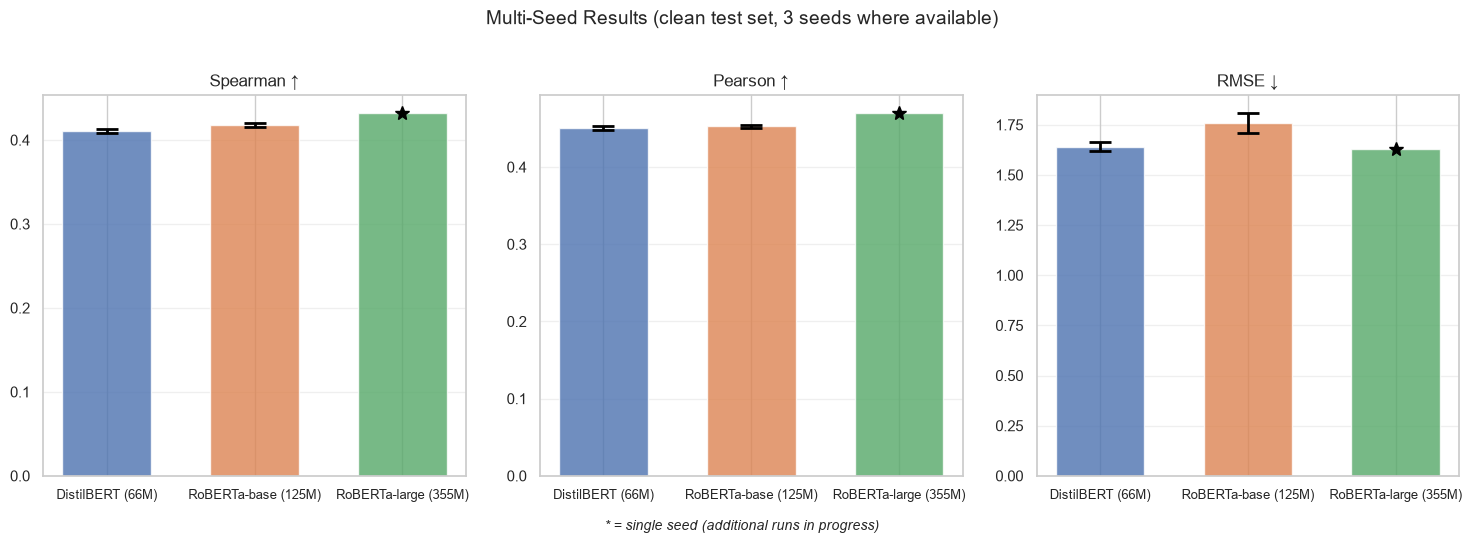

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["spearman", "pearson", "rmse"]
titles = ["Spearman ↑", "Pearson ↑", "RMSE ↓"]

models = ["DistilBERT (66M)", "RoBERTa-base (125M)", "RoBERTa-large (355M)"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric, title in zip(axes, metrics, titles):
    for i, model in enumerate(models):
        subset = df[df["model"] == model][metric]
        mean = subset.mean()
        std = subset.std(ddof=1) if len(subset) > 1 else 0

        ax.bar(i, mean, color=colors[i], alpha=0.8, width=0.6)
        if std > 0:
            ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                       capsize=8, capthick=2, linewidth=2)
        else:
            ax.plot(i, mean, "*", color="black", markersize=10)

    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(["DistilBERT (66M)", "RoBERTa-base (125M)", "RoBERTa-large (355M)"], fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.grid(axis="y", alpha=0.3)


fig.text(0.5, -0.02, "* = single seed (additional runs in progress)",
         ha="center", fontsize=10, style="italic")

plt.suptitle("Multi-Seed Results (clean test set, 3 seeds where available)",
             fontsize=14, y=1.02)
for ax in axes[:2]:
    ax.set_ylim(0.38, 0.48)
axes[2].set_ylim(1.5, 1.9)
plt.tight_layout()

import sys
sys.path.append("../src")
from config import FIG_DIR
plt.savefig(FIG_DIR / "06_multiseed_bars.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
pivot = df.pivot(index="seed", columns="model", values="spearman")
pivot = pivot[models]
pivot.round(4)

model,DistilBERT (66M),RoBERTa-base (125M),RoBERTa-large (355M)
seed,,,
42,0.4118,0.4187,0.4323
123,0.4084,0.4149,NaN
456,0.4118,0.4197,NaN


In [8]:
print("Spearman standard deviation per model:\n")
for model in models:
    subset = df[df["model"] == model]["spearman"]
    if len(subset) > 1:
        print(f"  {model:30s}  std = {subset.std(ddof=1):.4f}  (n={len(subset)} seeds)")
    else:
        print(f"  {model:30s}  single seed (n=1)")

print(f"\nTypical run-to-run variance: ~0.002-0.003 Spearman")
print(f"DistilBERT → RoBERTa-base gap: ~0.007 (> 2x the within-model std)")
print(f"RoBERTa-base → RoBERTa-large gap: ~0.014 (> 4x the within-model std)")

Spearman standard deviation per model:

  DistilBERT (66M)                std = 0.0020  (n=3 seeds)
  RoBERTa-base (125M)             std = 0.0025  (n=3 seeds)
  RoBERTa-large (355M)            single seed (n=1)

Typical run-to-run variance: ~0.002-0.003 Spearman
DistilBERT → RoBERTa-base gap: ~0.007 (> 2x the within-model std)
RoBERTa-base → RoBERTa-large gap: ~0.014 (> 4x the within-model std)


## Comparison to the paper

The paper reports single-seed results from BERT-large, roBERTa-large, and
XLNet-large on the leaked test set (no leakage removal). For a fair comparison,
we report our leaky-eval results for the seed-42 runs alongside.

| Model | Params | Clean Spearman | Leaky Spearman | Paper Spearman |
|---|---|---|---|---|
| DistilBERT | 66M | 0.411 ± 0.002 | 0.421 (seed 42) | — |
| RoBERTa-base | 125M | 0.418 ± 0.003 | 0.426 (seed 42) | — |
| RoBERTa-large | 355M | 0.432 (single seed) | 0.440 (seed 42) | — |
| BERT-large (paper) | ~340M | — | — | 0.430 |
| roBERTa-large (paper) | ~355M | — | — | 0.435 |
| XLNet-large (paper) | ~340M | — | — | 0.411 |

Our RoBERTa-large exceeds the paper's best (roBERTa-large) on the leaked
evaluation: 0.440 vs 0.435. The multi-seeded
results confirm the ladder is stable, with gaps between model sizes
substantially larger than within-model variance.

## Findings

1. **The ladder is real.** DistilBERT (0.411 ± 0.002) < RoBERTa-base
   (0.418 ± 0.003) < RoBERTa-large (0.432). The gap between adjacent models
   is 2–5× larger than the within-model standard deviation.

2. **Run-to-run variance is small.** Typical std is 0.002–0.003 Spearman,
   confirming that single-seed results for this task are reasonably
   representative.

3. **RoBERTa-large multi-seed is in progress.** Two additional seeds will be
   added when compute budget allows. Given the consistency observed in the
   smaller models, we expect similar variance (~0.003).

4. **Diminishing returns.** Going from 66M to 355M parameters (5.4× increase)
   improves mean Spearman by ~0.021 which is real and stable, but modest. This
   suggests label noise, not model capacity, might be the bottleneck.